# 🚢 Intelligence Lab – ECE | NOTEBOOK B : PROJET ÉTUDIANT
## Titanic – Prédire la Survie des Passagers

---

### 🧠 Contexte Métier

Le naufrage du **RMS Titanic** (15 avril 1912) est l'une des catastrophes maritimes les plus connues de l'histoire.  
Sur les **2 224 passagers et membres d'équipage**, seulement **~710 ont survécu** — soit environ 32%.  
À partir du profil de chaque passager (âge, sexe, classe, tarif du billet, port d'embarquement…), on cherche à **prédire si un passager a survécu (1) ou non (0)**.  
C'est un problème de **classification binaire** avec des données réelles, des valeurs manquantes et des variables hétérogènes — un excellent terrain d'entraînement au pipeline ML complet 🛠️.

### 📋 Description des colonnes du dataset

| Colonne | Type | Description |
|---------|------|-------------|
| `survived` | int (0/1) | 🎯 **Cible** – Survie (1 = oui, 0 = non) |
| `pclass` | int (1/2/3) | Classe du billet (1 = 1ère, 3 = 3ème) |
| `sex` | str | Sexe du passager |
| `age` | float | Âge — contient des **valeurs manquantes** |
| `sibsp` | int | Nombre de frères/sœurs/conjoints à bord |
| `parch` | int | Nombre de parents/enfants à bord |
| `fare` | float | Tarif du billet |
| `embarked` | str | Port d'embarquement (C = Cherbourg, Q = Queenstown, S = Southampton) |
| `deck` | str | Pont — **~77% de valeurs manquantes** |
| `class` | str | Classe en texte — redondant avec `pclass` |
| `alone` | bool | Le passager voyage-t-il seul ? |

> ⚠️ Certaines colonnes contiennent des **valeurs manquantes** : c'est exactement ce qui rend ce dataset intéressant pédagogiquement !

### 🎯 Objectif Pédagogique

Dans ce projet, vous allez :

1. ✅ **Vérifier la qualité** du dataset (types, NaN, distributions)
2. 🧹 **Nettoyer** les données (gérer les valeurs manquantes, supprimer les colonnes inutiles)
3. 📊 **Visualiser** les données et les liens avec la survie *(quelques graphiques à compléter !)*
4. 🛠️ **Feature Engineering** : créer de nouvelles variables pertinentes
5. 🔄 **Encoder** les variables catégorielles pour les rendre utilisables par le modèle
6. ✂️ **Réaliser un split** Train / Validation / Test *(vous pouvez ajuster les proportions !)*
7. 🤖 **Entraîner un modèle** et **analyser les résultats**

---

> 📌 **Comment lire ce notebook ?**
> - 🟦 **Blocs EXÉCUTER** → Lancez la cellule telle quelle, observez le résultat
> - 🟧 **Blocs MODIFIER** → Changez les valeurs indiquées et observez l'impact
> - 🟩 **Blocs À COMPLÉTER** → Écrivez le code manquant (guidé par des commentaires)
> - ❓ **Questions** → Répondez dans la cellule Markdown prévue à cet effet

---

### 🌍 5 Sources d'Open Data à connaître

| # | Source | Description |
|---|--------|-------------|
| 🏆 | [Kaggle](https://www.kaggle.com/datasets) | Compétitions + datasets variés |
| 🔍 | [Google Dataset Search](https://datasetsearch.research.google.com/) | Moteur de recherche de datasets |
| 🇫🇷 | [Data.gouv.fr](https://www.data.gouv.fr/) | Données publiques françaises |
| 🤗 | [HuggingFace Datasets](https://huggingface.co/datasets) | NLP, vision, tabular, multi-modal |
| 📂 | [UCI Repository](https://archive.ics.uci.edu/ml/) | Référence académique classique |

---
## 📦 1. Chargement & Aperçu des Données

🟦 **EXÉCUTER** — Cette cellule charge le dataset et affiche les informations de base. Aucune modification nécessaire.

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import ssl
from urllib.error import URLError
from urllib.request import urlopen

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# ── Palette ECE ──────────────────────────────────────────────────────────────
ORANGE = "#E69635"
TEAL   = "#306F78"
PALETTE = [TEAL, ORANGE]
sns.set_theme(style="whitegrid", palette=PALETTE)

# ── Chargement du dataset Titanic ─────────────────────────────────────────────
try:
    df = sns.load_dataset("titanic")
except Exception as e:
    titanic_url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
    ssl_context = ssl._create_unverified_context()
    with urlopen(titanic_url, context=ssl_context) as response:
        df = pd.read_csv(response)

print(f"✅ Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"   Cible 'survived' : 0 = Non-survie ({(df['survived']==0).sum()}) | 1 = Survie ({(df['survived']==1).sum()})")

✅ Dataset chargé : 891 lignes × 15 colonnes
   Cible 'survived' : 0 = Non-survie (549) | 1 = Survie (342)


In [2]:
# 🟩 À COMPLÉTER ──────────────────────────────────────────────────────────────

# Aperçu des 15 premières lignes

In [3]:
# 🟦 EXÉCUTER — Statistiques descriptives
df.describe(include="all").round(2)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.00,891.00,891,714.00,891.00,891.00,891.00,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.38,2.31,NaN,29.70,0.52,0.38,32.20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.49,0.84,NaN,14.53,1.10,0.81,49.69,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.00,1.00,NaN,0.42,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.00,2.00,NaN,20.12,0.00,0.00,7.91,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.00,3.00,NaN,28.00,0.00,0.00,14.45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.00,3.00,NaN,38.00,1.00,0.00,31.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 🔍 2. Aperçu & Qualité des Données

Avant tout traitement, on vérifie systématiquement :
- **Valeurs manquantes** : combien ? Dans quelles colonnes ?
- **Types** : sont-ils cohérents ?
- **Distribution de la cible** : les classes sont-elles équilibrées ?

🟩 ***À COMPLÉTER**— Observez les résultats attentivement, vous en aurez besoin pour répondre aux questions.

In [4]:
# 🟩 À COMPLÉTER ──────────────────────────────────────────────────────────────
# Calculez et affichez les valeurs manquantes du dataset
#
# Étape 1 : compter les NaN par colonne et trier du plus grand au plus petit
# missing = df.isnull().___().sort_values(ascending=___)
#
# Étape 2 : calculer le pourcentage (NaN / nombre total de lignes × 100)
# missing_pct = (missing / ___ * 100).round(1)
#
# Étape 3 : créer un DataFrame récap avec les deux colonnes
# missing_report = pd.DataFrame({'Nombre de NaN': ___, 'Pourcentage (%)': ___})
#
# Étape 4 : ne garder que les colonnes qui ont au moins 1 NaN
# missing_with_nan = missing_report[missing_report[___] > 0]
#
# Étape 5 : afficher le résultat
# if missing_with_nan.___:
#     print("✅ Aucune valeur manquante.")
# else:
#     print(f"⚠️  {len(___)} colonne(s) avec des valeurs manquantes :")
#     display(___)

pass  # Supprimez cette ligne une fois votre code écrit

In [5]:
# 🟩 À COMPLÉTER ──────────────────────────────────────────────────────────────
# Affichez un graphique en barres de la distribution de la survie
#
# Étape 1 : compter les passagers par valeur de 'survived' et renommer les labels
# surv_counts = df['survived'].value_counts().rename({0: '___', 1: '___'})
#
# Étape 2 : créer la figure
# fig, ax = plt.subplots(figsize=(5, 4))
#
# Étape 3 : tracer les barres (utilisez color=PALETTE, edgecolor='white', width=0.5)
# surv_counts.plot(kind='___', ___, ax=ax)
#
# Étape 4 : ajouter titre, labels des axes, et rotation=0 sur les x
# ax.set_title('___', fontsize=13, fontweight='bold')
# ax.set_xlabel('___')
# ax.set_ylabel('___')
# ax.set_xticklabels(['Non-survie', 'Survie'], rotation=___)
#
# Étape 5 : afficher le nombre au-dessus de chaque barre
# for p in ax.patches:
#     ax.annotate(str(int(p.get_height())),
#                 (p.get_x() + p.get_width()/2, p.get_height() + 5),
#                 ha='center', fontsize=11)
#
# plt.tight_layout()
# plt.show()

pass  # Supprimez cette ligne une fois votre code écrit

### ❓ Question 1

> **a)** Quelles colonnes ont des valeurs manquantes ? Que proposez-vous pour chacune ?  
> **b)** Le dataset est-il équilibré ? Qu'est-ce que ça change pour l'accuracy ?

---
*✏️ Répondez ici :*

a) ...

b) ...

---
## 🧹 3. Nettoyage du Dataset

Contrairement au dataset Breast Cancer, Titanic contient :
- Des **valeurs manquantes** dans `age`, `embarked`, `deck`
- Des **colonnes redondantes** ou inutiles à supprimer
- Des **variables catégorielles** à encoder plus tard

### Étape 1 – Suppression des colonnes inutiles

🟦 **EXÉCUTER** — On supprime les colonnes qui n'apportent pas d'information utile au modèle.

In [6]:
# ── Suppression des colonnes inutiles ────────────────────────────────────────
# 'class'       : doublon exact de 'pclass' (même info, juste en texte)
# 'deck'        : ~77% de NaN → trop incomplète pour être utile
# 'embark_town' : doublon exact de 'embarked' (nom complet vs lettre)
# 'alive'       : fuite de données — c'est 'survived' écrit en texte !

cols_to_drop = ['class', 'deck', 'embark_town', 'alive']
df_clean = df.drop(columns=cols_to_drop).copy()

print(f"✅ Colonnes conservées ({df_clean.shape[1]}) :")
print(df_clean.columns.tolist())

df_clean.head(15)

✅ Colonnes conservées (11) :
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'who', 'adult_male', 'alone']


,survived,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,alone
0,0,3,male,22.0,1,0,7.2500,S,man,True,False
1,1,1,female,38.0,1,0,71.2833,C,woman,False,False
2,1,3,female,26.0,0,0,7.9250,S,woman,False,True
3,1,1,female,35.0,1,0,53.1000,S,woman,False,False
4,0,3,male,35.0,0,0,8.0500,S,man,True,True
5,0,3,male,NaN,0,0,8.4583,Q,man,True,True
6,0,1,male,54.0,0,0,51.8625,S,man,True,True
7,0,3,male,2.0,3,1,21.0750,S,child,False,False
8,1,3,female,27.0,0,2,11.1333,S,woman,False,False
9,1,2,female,14.0,1,0,30.0708,C,child,False,False


### Étape 2 – Imputation de `age`

Il manque ~20% des âges. Plutôt que de supprimer ces lignes ou de mettre une valeur unique, on utilise une **imputation par groupe** : on remplace l'âge manquant par la médiane des passagers de même classe et même sexe — ce qui est beaucoup plus réaliste.

🟦 **EXÉCUTER** — Observez les médianes par groupe avant et après imputation.

In [7]:
# ── Imputation de 'age' par médiane par groupe (pclass, sex) ─────────────────
age_medians = df_clean.groupby(['pclass', 'sex'])['age'].median()
print("Médianes d'âge par groupe (classe × sexe) :")
print(age_medians)

def impute_age(row):
    if pd.isnull(row['age']):
        return age_medians.loc[row['pclass'], row['sex']]
    return row['age']

df_clean['age'] = df_clean.apply(impute_age, axis=1)
print(f"\n✅ Valeurs manquantes dans 'age' après imputation : {df_clean['age'].isnull().sum()}")

Médianes d'âge par groupe (classe × sexe) :
pclass  sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: age, dtype: float64

✅ Valeurs manquantes dans 'age' après imputation : 0


### Étape 3 – Imputation de `embarked`

Seulement 2 valeurs manquantes. On remplace par le **port le plus fréquent** (mode).

🟦 **EXÉCUTER**

In [8]:
# ── Imputation de 'embarked' ─────────────────────────────────────────────────
most_frequent_port = df_clean['embarked'].mode()[0]
df_clean['embarked'] = df_clean['embarked'].fillna(most_frequent_port)

print(f"Port le plus fréquent utilisé pour l'imputation : '{most_frequent_port}'")
print(f"Valeurs manquantes dans 'embarked' après imputation : {df_clean['embarked'].isnull().sum()}")
print(f"\n✅ Dataset propre : {df_clean.isnull().sum().sum()} valeur(s) manquante(s) au total")

Port le plus fréquent utilisé pour l'imputation : 'S'
Valeurs manquantes dans 'embarked' après imputation : 0

✅ Dataset propre : 0 valeur(s) manquante(s) au total


### ❓ Question 2

> **a)** Pourquoi imputer l'âge par la **médiane par groupe** plutôt que la médiane globale ?  
> **b)** On a supprimé `deck` (77% NaN). À quel pourcentage de NaN faut-il, selon vous, supprimer plutôt qu'imputer ?

---
*✏️ Répondez ici :*

a) ...

b) ...

---
## 📊 4. Visualisation & Compréhension

Avant de modéliser, on explore visuellement les **liens entre les variables et la survie**.
Ces graphiques sont **tous à compléter** 🟩 — ils n'impactent pas le dataset, vous pouvez les faire dans n'importe quel ordre.

> 💡 Ces visualisations sont importantes : elles vous aideront à répondre à la Question 3 et à choisir vos features engineering !

In [9]:
# 🟩 À COMPLÉTER – Graphique 1 : Taux de survie par Genre et par Classe
#
# Créez une figure avec 2 sous-graphiques côte à côte.
# Pour chaque sous-graphique, calculez le taux de survie moyen par groupe (groupby + mean)
# et affichez le résultat en barres verticales.
#
# Sous-graphique gauche : survie selon 'sex' → renommez 'female'/'male' en français
# Sous-graphique droit  : survie selon 'pclass' → 3 barres (1ère, 2ème, 3ème classe)
#
# Conseils :
# → fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# → .plot(kind='bar', ax=axes[0], edgecolor='white', width=0.5)
# → Pour l'axe Y en pourcentage : ax.yaxis.set_major_formatter(...)
# → Ajoutez un titre global avec fig.suptitle(...)

# fig, axes = plt.subplots(...)

# --- Graphique gauche ---
# sex_surv = df_clean.groupby('___')['survived'].___().rename({...})
# sex_surv.plot(kind='bar', ax=axes[0], ...)
# axes[0].set_title('___')
# axes[0].set_ylabel('___')
# axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# --- Graphique droit ---
# pclass_surv = df_clean.groupby('___')['survived'].___().rename({...})
# pclass_surv.plot(kind='bar', ax=axes[1], ...)
# axes[1].set_title('___')
# axes[1].set_xticklabels([...], rotation=0)

# fig.suptitle('___')
# plt.tight_layout()
# plt.show()

pass  # Supprimez cette ligne une fois votre code écrit

In [10]:
# 🟩 À COMPLÉTER – Graphique 2 : Distribution de l'âge et du tarif par survie
#
# Créez une figure avec 2 histogrammes côte à côte
# Pour chaque graphique, tracez 2 histogrammes superposés : un pour les survivants (survived=1)
# et un pour les non-survivants (survived=0), avec alpha=0.6 pour la transparence
#
# Graphique gauche : distribution de l'âge ('age')
#   → bins=30, couleurs PALETTE[0] et PALETTE[1], labels 'Non-survie' et 'Survie'
#   → Titre : "Distribution de l'âge par survie", xlabel='Âge', ylabel='Fréquence'
#
# Graphique droit : distribution du tarif en log (np.log1p(fare))
#   → Même principe, xlabel='log(Tarif + 1)'
#   → Astuce : np.log1p(x) = log(x+1), évite les problèmes si fare=0
#
# Indice de structure :
# fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# for cls, color, label in zip([0, 1], PALETTE, ['Non-survie', 'Survie']):
#     axes[0].hist(df_clean[df_clean['survived']==___]['age'], bins=___, alpha=0.6,
#                  color=___, label=___, edgecolor='white')
#     axes[1].hist(np.log1p(df_clean[df_clean['survived']==___]['fare']), ...)
# axes[0].legend()
# axes[1].legend()
# plt.tight_layout()
# plt.show()

pass  # Supprimez cette ligne une fois votre code écrit

### 🟩 À COMPLÉTER – Graphique 3 : Taux de survie par port d'embarquement

Même principe que le graphique Genre/Classe : groupez par `embarked` et calculez la moyenne de `survived`.

**Indications :**
- `embarked_surv = df_clean.groupby('embarked')['survived'].mean()`
- Renommez : `'C'` → `'Cherbourg'`, `'Q'` → `'Queenstown'`, `'S'` → `'Southampton'`
- Barres verticales, `color=[TEAL, '#5B9E8A', ORANGE]`, titre `'Taux de survie par port d\'embarquement'`
- Formatez l'axe Y en pourcentage (comme le graphique 1)

In [11]:
# 🟩 À COMPLÉTER ──────────────────────────────────────────────────────────────
# Graphique : Taux de survie par port d'embarquement

# Étape 1 : calculer le taux de survie par port
# embarked_surv = df_clean.groupby(...)['survived'].mean()

# Étape 2 : renommer les ports (C, Q, S → noms complets)
# embarked_surv = embarked_surv.rename({...})

# Étape 3 : créer le graphique
# fig, ax = plt.subplots(figsize=(6, 4))
# embarked_surv.plot(kind='bar', ...)
# ...
# plt.show()

pass  # Supprimez cette ligne une fois votre code écrit

### 🟩 À COMPLÉTER – Graphique 4 : Heatmap de corrélation

Créez une heatmap de corrélation entre les variables numériques du dataset.

**Indications :**
- Utilisez les colonnes : `['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']`
- Calculez la matrice de corrélation avec `.corr()`
- Affichez-la avec `sns.heatmap(...)` en ajoutant `annot=True` pour voir les valeurs
- Ajoutez un masque triangulaire pour ne pas afficher les doublons (comme dans le Notebook A)

In [12]:
# 🟩 À COMPLÉTER ──────────────────────────────────────────────────────────────
# Graphique : Heatmap de corrélation

# Étape 1 : sélectionner les colonnes numériques
# cols_corr = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
# corr = df_clean[cols_corr].corr()

# Étape 2 : créer le masque triangulaire
# mask = np.triu(np.ones_like(corr, dtype=bool))

# Étape 3 : afficher la heatmap
# fig, ax = plt.subplots(figsize=(8, 6))
# sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
# ax.set_title('Heatmap de corrélation', fontsize=13, fontweight='bold')
# plt.tight_layout()
# plt.show()

pass  # Supprimez cette ligne une fois votre code écrit

### ❓ Question 3

> **a)** Quelle variable semble la **plus utile** pour prédire la survie ? Justifiez avec les graphiques.  
> **b)** Y a-t-il un groupe d'âge qui survit mieux ? Pourquoi selon vous ?  
> **c)** Les passagers de Cherbourg survivent-ils mieux ? Selon vous, pourquoi ?

---
*✏️ Répondez ici :*

a) ...

b) ...

c) ...

---
## 🛠️ 5. Feature Engineering

Le **Feature Engineering** consiste à **créer de nouvelles variables** à partir de celles qui existent déjà.  
C'est l'étape la plus créative du pipeline ML.

> 🧪 **L'objectif n'est pas de créer des features parfaites.** Ce n'est pas parce qu'une idée semble logique qu'elle améliorera forcément la précision du modèle — et inversement. Ce que vous faites ici, c'est **expérimenter** : créez des variables, entraînez le modèle, regardez la précision et le graphique d'importance. Ensuite, revenez en arrière, enlevez une feature, changez un seuil, et observez l'effet. C'est comme ça qu'on construit un bon modèle.

> 💡 **Attention** : certaines colonnes du dataset sont déjà de l'information encodée — par exemple, `alone` indique déjà si le passager voyage seul. Avant de créer une nouvelle feature, vérifiez qu'elle n'existe pas déjà sous une autre forme !

---

### 🟦 EXÉCUTER – Deux features sont déjà construites

Observez leur impact sur le taux de survie avant de créer les vôtres.

In [13]:
# ── Features fournies ────────────────────────────────────────────────────────

# Feature 1 : Taille de la famille (le passager lui-même + ses proches à bord)
df_clean['family_size'] = df_clean['sibsp'] + df_clean['parch'] + 1

# Feature 2 : Voyage seul
# 💡 Le dataset contient déjà une colonne 'alone' (booléen : True/False).
# On la réencode simplement en entier (True → 1, False → 0) pour l'utiliser dans le modèle.
df_clean['is_alone'] = df_clean['alone'].astype(int)

print('✅ Features créées : family_size, is_alone')
print()
print('Taux de survie par taille de famille :')
print(df_clean.groupby('family_size')['survived'].mean().round(2).rename('taux_survie').to_string())
print()
print(f"Voyage seul → survie : {df_clean[df_clean['is_alone']==1]['survived'].mean():.1%}")
print(f"En famille  → survie : {df_clean[df_clean['is_alone']==0]['survived'].mean():.1%}")


✅ Features créées : family_size, is_alone

Taux de survie par taille de famille :
family_size
1     0.30
2     0.55
3     0.58
4     0.72
5     0.20
6     0.14
7     0.33
8     0.00
11    0.00

Voyage seul → survie : 30.4%
En famille  → survie : 50.6%


### 🟩 À COMPLÉTER – Feature 3 : `fare_group`

Le tarif du billet (`fare`) est une variable continue qui varie énormément d'un passager à l'autre.  
Pensez-vous que diviser ce tarif en **catégories** pourrait être plus utile pour le modèle qu'une valeur brute ?

**Créez une colonne `fare_group`** qui regroupe les passagers selon leur tarif.  
Vous pouvez découper en tranches fixes (`pd.cut`) ou en groupes de taille égale (`pd.qcut`) — à vous de choisir.

Vérifiez ensuite : est-ce que le taux de survie varie d'un groupe à l'autre ?

In [14]:
# 🟩 À COMPLÉTER – Feature 3 : fare_group

# Idée : diviser 'fare' en catégories (ex: 3 groupes)
# df_clean['fare_group'] = pd.qcut(...) ou pd.cut(...)

# Vérification : affichez le taux de survie par groupe
# print(df_clean.groupby('fare_group')['survived'].mean().round(2))

pass  # Supprimez cette ligne une fois votre code écrit

### 🟩 À COMPLÉTER – Feature 4 : `age_group`

L'âge est une variable continue. Est-ce que le fait d'être un enfant, un adulte ou un sénior  
change les chances de survie ? Pensez à comment vous pourriez créer des tranches d'âge pertinentes.

**Créez une colonne `age_group`** avec les tranches qui vous semblent les plus logiques.  
Utilisez `pd.cut` avec les `bins` et `labels` de votre choix.

Vérifiez ensuite : est-ce que certaines tranches d'âge survivent nettement mieux que d'autres ?

In [15]:
# 🟩 À COMPLÉTER – Feature 4 : age_group

# Idée : diviser 'age' en tranches (enfant / adulte / sénior ?)
# df_clean['age_group'] = pd.cut(df_clean['age'], bins=[___], labels=[___]).astype(int)

# Vérification : affichez le taux de survie par tranche d'âge
# print(df_clean.groupby('age_group')['survived'].mean().round(2))

pass  # Supprimez cette ligne une fois votre code écrit

### 🟩 À COMPLÉTER – Feature 5 : `title`

Regardez la colonne `name` : chaque passager a un titre (`Mr`, `Mrs`, `Miss`, `Master`, `Dr`…).  
Ce titre concentre en un seul mot des informations sur le sexe, l'âge et le statut social.

**Extrayez ce titre** depuis la colonne `name` pour créer une colonne `title`.  
*Piste : le titre se trouve entre la virgule et le point dans le nom — une expression régulière peut aider.*

Une fois extraits, certains titres sont très rares (`Dr`, `Rev`, `Col`…).  
Pensez à les regrouper pour éviter trop de catégories.

Vérifiez : est-ce que le taux de survie diffère vraiment selon le titre ?

In [16]:
# 🟩 À COMPLÉTER – Feature 5 : title

# Étape 1 : extraire le titre depuis 'name' (indice : str.extract + regex)
# df_clean['title'] = df_clean['name'].str.extract(___)

# Étape 2 : regrouper les titres rares en une seule catégorie 'Rare'
# df_clean['title'] = df_clean['title'].replace([...], 'Rare')

# Étape 3 : vérifier le taux de survie par titre
# print(df_clean.groupby('title')['survived'].mean().round(2))

pass  # Supprimez cette ligne une fois votre code écrit

### 🟦 EXÉCUTER – Vérification des features créées

Cette cellule vérifie que toutes vos nouvelles colonnes sont bien présentes dans le dataset.

In [17]:
# ── Vérification finale du Feature Engineering ────────────────────────────────
expected_features = ['family_size', 'is_alone', 'fare_group', 'age_group', 'title']
print('🔎 Vérification des nouvelles features :')
print()
for feat in expected_features:
    if feat in df_clean.columns:
        n_unique = df_clean[feat].nunique()
        n_nan    = df_clean[feat].isnull().sum()
        status   = '✅' if n_nan == 0 else f'⚠️  {n_nan} NaN'
        print(f'  {status}  {feat:15s} → {n_unique} valeurs uniques')
    else:
        print(f'  ❌  {feat:15s} → non créée (à compléter)')

print()
print('Aperçu des nouvelles colonnes :')
cols_present = [c for c in expected_features if c in df_clean.columns]
if cols_present:
    display(df_clean[cols_present].head(10))

🔎 Vérification des nouvelles features :

  ✅  family_size     → 9 valeurs uniques
  ✅  is_alone        → 2 valeurs uniques
  ❌  fare_group      → non créée (à compléter)
  ❌  age_group       → non créée (à compléter)
  ❌  title           → non créée (à compléter)

Aperçu des nouvelles colonnes :


,family_size,is_alone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1
5,1,1
6,1,1
7,5,0
8,3,0
9,2,0


---
## 🔄 6. Encodage & Normalisation

Les algorithmes de ML n'acceptent que des **données numériques**.  
Il faut donc :
1. **Encoder** les variables catégorielles (`sex`, `embarked`, `title`) → chiffres
2. **Normaliser** les variables numériques continues (`age`, `fare`, `family_size`) → même échelle [0, 1]

> 💡 On utilise le **MinMaxScaler** (normalisation 0–1). Pour `title`, on applique un **One-Hot Encoding** comme pour `embarked`.

🟦 **EXÉCUTER** — Ces cellules préparent le dataset final pour l'entraînement.

In [18]:
# ── Encodage de 'sex' ────────────────────────────────────────────────────────
df_clean['sex_enc'] = df_clean['sex'].map({'male': 0, 'female': 1})

# ── One-Hot Encoding de 'embarked' ───────────────────────────────────────────
embarked_dummies = pd.get_dummies(df_clean['embarked'], prefix='embarked', drop_first=True)
df_clean = pd.concat([df_clean, embarked_dummies], axis=1)

# ── One-Hot Encoding de 'title' (si créée par l'étudiant) ────────────────────
if 'title' in df_clean.columns:
    title_dummies = pd.get_dummies(df_clean['title'], prefix='title', drop_first=True)
    df_clean = pd.concat([df_clean, title_dummies], axis=1)
    title_cols = title_dummies.columns.tolist()
else:
    title_cols = []

print('✅ Encodages effectués :')
print(f'   sex_enc         : male=0, female=1')
print(f'   embarked → OHE  : {embarked_dummies.columns.tolist()}')
if title_cols:
    print(f'   title    → OHE  : {title_cols}')
else:
    print('   title : non créée — encodage ignoré')


✅ Encodages effectués :
   sex_enc         : male=0, female=1
   embarked → OHE  : ['embarked_Q', 'embarked_S']
   title : non créée — encodage ignoré


In [19]:
# ── Définition des features & normalisation ──────────────────────────────────

# Features numériques à normaliser [0, 1]
num_cols = ['age', 'fare', 'family_size']

# Features catégorielles (pas besoin de normalisation)
# 🟧 MODIFIER – vous pouvez ajouter ou retirer des features ici
base_cat = [
    'pclass', 'sex_enc', 'sibsp', 'parch', 'is_alone',
    'embarked_Q', 'embarked_S',
    'fare_group', 'age_group'
]

# Récupère automatiquement les colonnes One-Hot de 'title' si elles existent
title_ohe_cols = [c for c in df_clean.columns if c.startswith('title_')]
cat_cols = base_cat + title_ohe_cols

# Sécurité : on retire les colonnes absentes
cat_cols = [c for c in cat_cols if c in df_clean.columns]

# Normalisation [0, 1]
scaler = MinMaxScaler()
X_num = pd.DataFrame(
    scaler.fit_transform(df_clean[num_cols]),
    columns=[c + '_norm' for c in num_cols]
)

# Assemblage final
X = pd.concat([
    X_num.reset_index(drop=True),
    df_clean[cat_cols].reset_index(drop=True)
], axis=1)
y = df_clean['survived'].reset_index(drop=True)

print(f'✅ Dataset prêt : X = {X.shape} | y = {y.shape}')
print(f'   Features utilisées ({len(X.columns)}) : {X.columns.tolist()}')


✅ Dataset prêt : X = (891, 10) | y = (891,)
   Features utilisées (10) : ['age_norm', 'fare_norm', 'family_size_norm', 'pclass', 'sex_enc', 'sibsp', 'parch', 'is_alone', 'embarked_Q', 'embarked_S']


---
## ✂️ 7. Split Train / Validation / Test

### 🟧 MODIFIER – Ajustez les proportions du split

Le split définit combien de données sont utilisées pour **entraîner**, **valider** et **tester** le modèle.  
Il n'y a pas de proportion universelle — mais quelques règles à respecter :

| Règle | Explication |
|-------|-------------|
| Le Train doit être le plus grand | Le modèle apprend mieux avec plus de données |
| Test ≥ 10% | En dessous, les résultats ne sont pas représentatifs |
| Val et Test souvent équilibrés | Pour une évaluation fiable |

**Modifiez `TEST_SIZE` et `VAL_RATIO`** dans la cellule ci-dessous pour tester différentes répartitions.  
Observez comment les tailles des ensembles changent — et plus tard, si les résultats changent aussi.

> ⚠️ **Contraintes :** `TEST_SIZE` doit être entre `0.20` et `0.40` | `VAL_RATIO` doit rester à `0.50` pour garder Validation = Test

In [20]:
# 🟧 MODIFIER – Ajustez ces deux valeurs ──────────────────────────────────────

TEST_SIZE  = 0.30   # Proportion réservée à Validation+Test (entre 0.20 et 0.40)
VAL_RATIO  = 0.50   # Ratio Val/Test dans la portion réservée (0.50 = équilibré)

# ─────────────────────────────────────────────────────────────────────────────
# Ne modifiez pas ce qui suit
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=VAL_RATIO, random_state=42, stratify=y_temp
)

n_total = len(X)
print("✅ Split effectué :")
print(f"   Entraînement : {X_train.shape[0]} lignes ({X_train.shape[0]/n_total*100:.1f}%)")
print(f"   Validation   : {X_val.shape[0]} lignes ({X_val.shape[0]/n_total*100:.1f}%)")
print(f"   Test         : {X_test.shape[0]} lignes ({X_test.shape[0]/n_total*100:.1f}%)")
print(f"\n   Taux de survie – Train: {y_train.mean():.3f} | Val: {y_val.mean():.3f} | Test: {y_test.mean():.3f}")

✅ Split effectué :
   Entraînement : 623 lignes (69.9%)
   Validation   : 134 lignes (15.0%)
   Test         : 134 lignes (15.0%)

   Taux de survie – Train: 0.384 | Val: 0.388 | Test: 0.381


---
## 🤖 8. Entraînement du Modèle

On utilise une **Régression Logistique** — un modèle simple, rapide et interprétable, idéal pour commencer.

### 🟧 MODIFIER – Testez différents hyperparamètres

Le paramètre `C` contrôle la **régularisation** du modèle :
- Un `C` trop **petit** → modèle trop contraint → risque de **sous-apprendre** (ne capture pas assez les patterns)
- Un `C` trop **grand** → modèle trop libre → risque de **sur-apprendre** (trop ajusté aux données d'entraînement)

> ⚠️ Il n'existe pas de valeur universelle : l'effet de `C` dépend du dataset, des features et d'autres paramètres. Testez, observez, et tirez vos propres conclusions !

In [21]:
# 🟧 MODIFIER – Changez la valeur de C pour expérimenter ──────────────────────

C_PARAM = 1.0    # 🟧 Modifiez cette valeur et observez l'effet sur la précision

# ─────────────────────────────────────────────────────────────────────────────
model = LogisticRegression(max_iter=1000, random_state=42, C=C_PARAM)
model.fit(X_train, y_train)

acc_test = accuracy_score(y_test, model.predict(X_test))
print(f"✅ Modèle entraîné avec C = {C_PARAM}")
print(f"🎯 Précision sur le jeu de test : {acc_test*100:.2f}%")

✅ Modèle entraîné avec C = 1.0
🎯 Précision sur le jeu de test : 76.87%


---
## 📊 9. Résultats & Analyse

🟦 **EXÉCUTER** — Le dashboard ci-dessous résume les résultats finaux : précision du modèle, répartition du split et matrice de confusion.

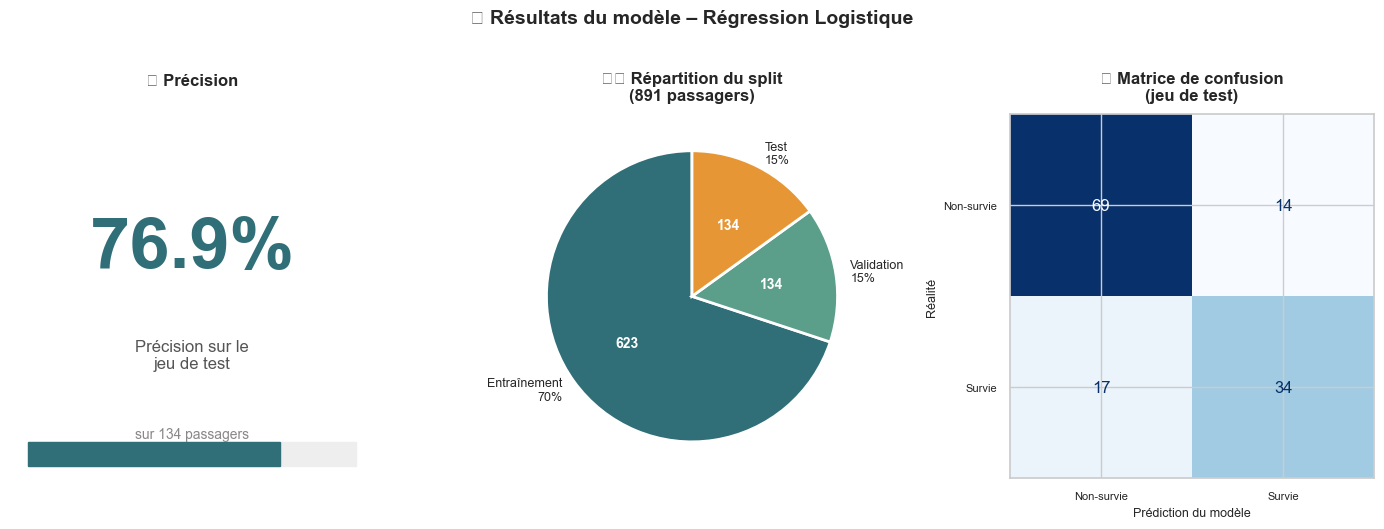

In [22]:
# ── Dashboard de résultats ────────────────────────────────────────────────────
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig = plt.figure(figsize=(14, 5), facecolor='white')
fig.suptitle('📊 Résultats du modèle – Régression Logistique', fontsize=14, fontweight='bold', y=1.02)

# ── Panneau 1 : Précision ─────────────────────────────────────────────────────
ax1 = fig.add_subplot(1, 3, 1)
ax1.set_facecolor('white')
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.axis('off')
ax1.text(0.5, 0.62, f"{acc_test*100:.1f}%",
         ha='center', va='center', fontsize=52, fontweight='bold', color=TEAL)
ax1.text(0.5, 0.35, "Précision sur le\njeu de test",
         ha='center', va='center', fontsize=12, color='#555555')
ax1.text(0.5, 0.15, f"sur {len(y_test)} passagers",
         ha='center', va='center', fontsize=10, color='#888888')
bar_bg  = plt.Rectangle((0.05, 0.07), 0.90, 0.06, color='#EEEEEE', transform=ax1.transAxes, clip_on=False)
bar_val = plt.Rectangle((0.05, 0.07), 0.90 * acc_test, 0.06, color=TEAL, transform=ax1.transAxes, clip_on=False)
ax1.add_patch(bar_bg)
ax1.add_patch(bar_val)
ax1.set_title('🎯 Précision', fontsize=12, fontweight='bold', pad=10)

# ── Panneau 2 : Répartition du split ─────────────────────────────────────────
ax2 = fig.add_subplot(1, 3, 2)
ax2.set_facecolor('white')
sizes   = [X_train.shape[0], X_val.shape[0], X_test.shape[0]]
labels  = [f'Entraînement\n{sizes[0]/n_total*100:.0f}%', f'Validation\n{sizes[1]/n_total*100:.0f}%', f'Test\n{sizes[2]/n_total*100:.0f}%']
colors2 = [TEAL, '#5B9E8A', ORANGE]
wedges, texts = ax2.pie(sizes, labels=labels, colors=colors2,
                         startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
for text in texts:
    text.set_fontsize(9)
for wedge, n in zip(wedges, sizes):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = 0.55 * np.cos(np.radians(angle))
    y_pos = 0.55 * np.sin(np.radians(angle))
    ax2.text(x, y_pos, str(n), ha='center', va='center', fontsize=10, fontweight='bold', color='white')
ax2.set_title(f'✂️ Répartition du split\n({n_total} passagers)', fontsize=12, fontweight='bold', pad=10)

# ── Panneau 3 : Matrice de confusion ─────────────────────────────────────────
ax3 = fig.add_subplot(1, 3, 3)
ax3.set_facecolor('white')
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Non-survie', 'Survie']
)
disp.plot(ax=ax3, colorbar=False, cmap='Blues')
ax3.set_title('🔍 Matrice de confusion\n(jeu de test)', fontsize=12, fontweight='bold', pad=10)
ax3.set_xlabel('Prédiction du modèle', fontsize=9)
ax3.set_ylabel('Réalité', fontsize=9)
ax3.tick_params(axis='x', labelsize=8)
ax3.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

### Importance des variables

🟦 **EXÉCUTER** — Ce graphique montre quelles variables ont le plus contribué aux décisions du modèle (via les coefficients de la régression logistique).

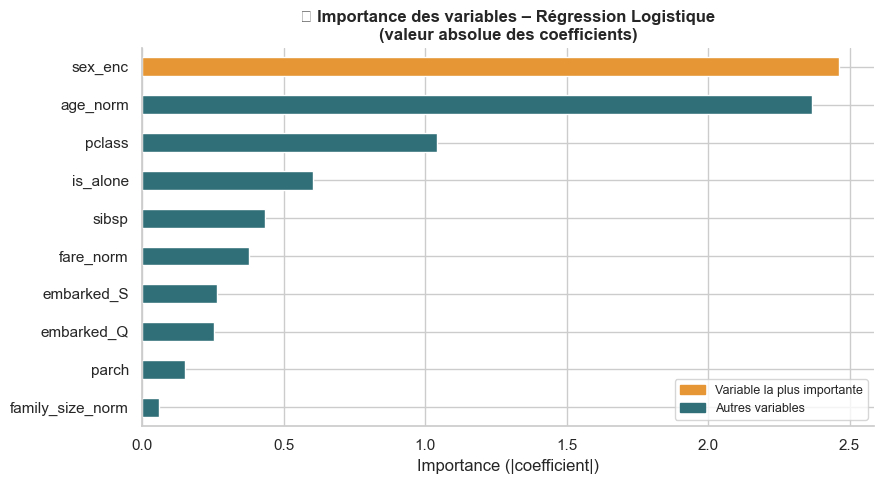

In [23]:
# ── Importance des features (coefficients de la régression logistique) ────────
importances = pd.Series(
    np.abs(model.coef_[0]),
    index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5), facecolor='white')
ax.set_facecolor('white')
colors = [ORANGE if v == importances.max() else TEAL for v in importances.values]
importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('📊 Importance des variables – Régression Logistique\n'
             '(valeur absolue des coefficients)', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance (|coefficient|)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
patch_best = mpatches.Patch(color=ORANGE, label='Variable la plus importante')
patch_rest = mpatches.Patch(color=TEAL, label='Autres variables')
ax.legend(handles=[patch_best, patch_rest], fontsize=9)
plt.tight_layout()
plt.show()

### ❓ Question 4

> **a)** Quelle variable est la **plus importante** selon le modèle ? Comparez avec ce que vous avez vu dans les graphiques.  
> **b)** Regardez la matrice de confusion : le modèle fait-il plus d'erreurs sur les survivants ou les non-survivants ?

---
*✏️ Répondez ici :*

a) ...

b) ...

### ❓ Question 5

> **a)** Pourquoi le modèle prédit-il mieux **après** nettoyage et feature engineering qu'avec les données brutes ?  
> **b)** Parmi les features que vous avez créées, laquelle a eu le plus d'impact selon le graphique d'importance ? Pourquoi selon vous ?

---
*✏️ Répondez ici :*

a) ...

b) ...

---
## 🏁 Bilan du Projet

### Récapitulatif de votre pipeline :

| Étape | Action réalisée |
|-------|-----------------|
| 📦 Chargement | Chargement du dataset Titanic (891 passagers, 15 colonnes) |
| 🔍 Qualité | Vérification des valeurs manquantes et de la distribution de la cible |
| 🧹 Nettoyage | Suppression des colonnes inutiles, imputation de `age` et `embarked` |
| 📊 Visualisation | Exploration des liens entre les variables et la survie |
| 🛠️ Feature Engineering | Création de nouvelles variables : `family_size`, `is_alone`, `fare_group`, `age_group`, `title` |
| 🔄 Encodage | Encodage des variables catégorielles + normalisation des variables numériques |
| ✂️ Split | Découpage stratifié en ensembles Train / Validation / Test |
| 🤖 Modèle | Entraînement d'une Régression Logistique et analyse des résultats |

---

## 🏆 Aller plus loin : la compétition Kaggle

Ce dataset provient d'une vraie compétition Kaggle toujours ouverte :  
**[Titanic – Machine Learning from Disaster](https://www.kaggle.com/competitions/titanic)**

Vous pouvez y soumettre vos prédictions et vous mesurer à des milliers de participants sur un **leaderboard mondial** 🌍  
Pour participer, il suffit de créer un compte gratuit sur [kaggle.com](https://www.kaggle.com), rejoindre la compétition, appliquer votre pipeline sur les données de test fournies et soumettre un fichier CSV de prédictions.

### Scores de référence :

Des scores de précision sont disponibles sur le leaderboard de la compétition.  
À titre d'indication, un pipeline simple peut déjà atteindre des scores corrects — et des modèles plus avancés permettent d'aller plus loin.

### Pour améliorer votre score :
- Testez d'autres algorithmes : **`RandomForestClassifier`**, **`GradientBoostingClassifier`**…
- Explorez l'optimisation des hyperparamètres avec **`GridSearchCV`**
- Créez de nouvelles features ou combinez des variables existantes
- Utilisez la **validation croisée** (`cross_val_score`) pour des estimations plus robustes